<a href="https://colab.research.google.com/github/jackieeee3/MATH-456/blob/Homeworks/MATH_456_HW0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MATH 456: Introduction to Numerical Analysis II - Habbershaw**
## **Unit 0 Homework**
### **Homework Submission Guidelines & Requirements**
* **Complete all parts.** Submit solutions for every part of every problem. For analysis questions, show sufficient work to justify your conclusions
* **Code submission required.** Any problem with a computational component must include:
  * the code you wrote (MATLAB or Python).
  * the key numerical outputs (tables/figures) referenced in your writeup.
  * the brief instructions on how to run your code (e.g., which script to run)

Submit code as `.m` or `.py` files (preferred), or include it clearly in an appendix. Your code should run as submitted. If randomness is used, set a fixed seed.

* **Collaboration and attribution.** You may discuss concepts at a high level with classmates, and you may use external resources (internet searches, notes, textbooks, and AI/LLM tools). However, any collaborators and any external resources *must* be credited. Include an *Attribution Statement* at the end of your submission listing: (i) collaborators, (ii) resources/tools used (including AI/LLM tools), and (iii) what assistance they provided. Do not share written solutions or code
* **Submission format.** Submit a single, clearly legible PDF for your written work. Each problem must begin on a new page and be labeled with the problem number/title. Figures must have labeled axes and captions.
* **Typesetting bonus (readability incentive).** Typed solutions (LaTeX or comparable software that cleanly typesets mathematics) receive a readability bonus of up to 2% of the course grade. Handwritten work is accepted it it is neat, fully legible, and well organized.
* **Academic integrity.** All work must comply with the course collaboration policy and Penn State academic integrity standards.

**Computing environment (MATLAB or Python).** You may complete computational parts in MATLAB or in Python using NumPy. To ensure consistent floating-point behavior, use **double precision** throughout. MATLAB uses double precision by default; in Python use `float / numpy.float64` (IEEE 754 double).

* **Python warning (integers):** In Python, `10**16` is an *exact integer*. To reproduce floating-point effects, write `x = 1e16` or `x = float(10**16)`.
* **Python warning (linear algebra):** Do not form `inv(A)` explicitly. Use MATLAB `A \b` or in Python `numpy.linalg.solve(A,b)`.

**Useful MATLAB-Python equivalences**

$\begin{array}{|c|c|c|}
  \hline
  \textbf{Task} & \textbf{MATLAB} & \textbf{Python/NumPy} \\
  \hline
  \text{machine epsilon} & \texttt{eps(1)} & \texttt{np.finto(float).eps} \\
  \text{local spacing at x} & \texttt{eps(x)} & \texttt{np.spacing(x)} \\
  \text{next float after x} & \texttt{nextafter(a, Inf)} & \texttt{np.nextafter(a, np.inf)} \\
  \text{compute vector 2-norm} & \texttt{norm(x, 2)} & \texttt{np.linalg.norm(x, 2)} \\
  \text{compute vector 1-norm} & \texttt{norm(x, 1)} & \texttt{np.linalg.norm(x, 1)} \\
  \text{compute vector } \infty\text{-norm} & \texttt{norm(x, Inf)} & \texttt{np.linalg.norm(x, np.inf)} \\
  \text{solve Ax = b} & \texttt{A\\b} & \texttt{np.linalg.solve(A, b)} \\
  \hline
\end{array}$

<div style="page-break-after: always;"></div>


# **Exercise 0.1** (Non-Associativity and Summation Order):
Floating-point arithmetic is not associative: (a + b) + c may differ from a + (b + c). This exercise explores how rounding interacts with accumulation.
1. **(Computational)** Let $x = 10^{16}$. Compute in MATLAB or Python:
$$(x + 1) - x, \quad (x + (1 - x)), \quad (x + 1) + (-x)$$
Then compare
$$(x + 1) + 1 \quad \text{versus} \quad x + (1 + 1)$$
Record all outputs and explain any differences you observe.

In [ ]:
import numpy as np
x = float(10**16)
print(f'x: {x}')
print(f'x: {x:.0f}')

x: 1e+16
x: 10000000000000000


First three computations:

In [ ]:
a = (x + 1) - x
b = (x + (1 - x))
c = (x + 1) + (-x)
print(f'a: {a:.0f}')
print(f'b: {b:.0f}')
print(f'c: {c:.0f}')

a: 0
b: 0
c: 0


Last two computations:

In [ ]:
d = (x + 1) + 1
e = x + (1 + 1)
print(f'd: {d:.0f}')
print(f'e: {e:.0f}')

d: 10000000000000000
e: 10000000000000002


For the first three computations, all outputs equal 0, when in reality, all outputs shoudl equal 1. For the last two computations, `d` is incorrect as it outputs the original `x` while `e` outputs the correct answer. I believe this is because the expression (1 + 1) is calculated first and is big enough to avoid floating-point errors.

2. **(Analysis)** Assume a floating-point model fl(a + b) = (a + b)(1 + $\delta$) with $|\delta| \le \epsilon_{\text{mach}}$ when no overflow/underflow occurs. Explain (quantitatively) why repeated addtion of small terms (i.e. terms whose magnitude is below the local floating-point resolution of the current partial sum, roughly $\epsilon_{\text{mach}}|S|$) to a large partial sum can stagnate.

As $|\delta| \le \epsilon_{\text{mach}}$, the number is incredibly small. Machine epsilon is the smallest positive number than when added to zero results in a number different from 1. As the number is increadibly small and when $|\delta| = \epsilon_{\text{mach}}$, the difference in the floating-point model is not noticeable. When $|\delta| < \epsilon_{\text{mach}}$, this implies that when $\delta$ is added to 1, it does not change and stays 1 so the floating-point model is essentially just (a + b)(1) = (a + b), stagnating.

3. **(Interpretation)** When summing many terms, what diagnostic would you trust more: (i) the number of terms summed, or (ii) the size of the current partial sum relative to the next term? State a practical rule of thumb for detecting when further summation is pointless in finite precision.

I would trust the second diagnostic: the size of the current partial sum relative to the next term. This tells you how large or small the terms are that you are summing. The number of terms summed, on the other hand, tell you nothing about the size of the terms. Therefore, you can have large round-off errors when summing multiple terms that cannot be represented by the computer. A practical rule of thumb would be to stop the summation when the term is less than or equal to machine epsilon.

<div style="page-break-after: always;"></div>

# **Exercise 0.2** (Stable Evaluation): $\sqrt{x^2 - 1} - x$
For large x, the expression $\sqrt{x^2 + 1} - x$ suffers from subtractive cancellation.
1. **(Computational)** For $x = 10^k$ with $k = 0, 2, 4, 6, 8,10, 12, 14,$ compute
$$f_1(x) = \sqrt{x^2 + 1} - x \quad \text{and} \quad f_2(x) = \frac{1}{\sqrt{x^2 + 1} - x}$$
Compare $f_1(x)$ and $f_2(x)$ and report the relative discrepancy between them.

In [ ]:
def expression(numbers, function):
  results = [function(num) for num in numbers]
  return results

Values for k:

In [ ]:
k = [0, 2, 4, 6, 8, 10, 12, 14]
print("k:", k)

k: [0, 2, 4, 6, 8, 10, 12, 14]


Outputs for x:

In [ ]:
x = lambda k: 10**k
results = expression(k, x)
print("x:", results)
print("x:",[f'{num:.5e}' for num in results])

x: [1, 100, 10000, 1000000, 100000000, 10000000000, 1000000000000, 100000000000000]
x: ['1.00000e+00', '1.00000e+02', '1.00000e+04', '1.00000e+06', '1.00000e+08', '1.00000e+10', '1.00000e+12', '1.00000e+14']


Outputs for $f_1(x)$:

In [ ]:
function_1 = lambda x_val: np.sqrt(float(x_val)**2 + 1) - float(x_val)
results_f1 = expression(results, function_1)
print("f1 Outputs:", [f'{num:.5f}' for num in results_f1])
print("f1 Outputs:", [f'{num:.5e}' for num in results_f1])

f1 Outputs: ['0.41421', '0.00500', '0.00005', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000']
f1 Outputs: ['4.14214e-01', '4.99988e-03', '5.00000e-05', '5.00004e-07', '0.00000e+00', '0.00000e+00', '0.00000e+00', '0.00000e+00']


Outputs for $f_2(x)$:

In [ ]:
function_2 = lambda x_val: 1 / (np.sqrt(float(x_val)**2 + 1) + float(x_val))
results_f2 = expression(results, function_2)
print("f2 Outputs:", [f'{num:.5f}' for num in results_f2])
print("f2 Outputs:", [f'{num:.5e}' for num in results_f2])

f2 Outputs: ['0.41421', '0.00500', '0.00005', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000']
f2 Outputs: ['4.14214e-01', '4.99988e-03', '5.00000e-05', '5.00000e-07', '5.00000e-09', '5.00000e-11', '5.00000e-13', '5.00000e-15']


Relative DIscrepancies Between $f_1(x)$ and $f_2(x)$:

In [ ]:
relative_discrepancy = [abs(f1 - f2) / abs(f2) if f2 != 0 else np.nan for f1, f2 in zip(results_f1, results_f2)]
print("Relative Discrepancies:", [f'{num:.15e}' for num in relative_discrepancy])

Relative Discrepancies: ['1.340157741654466e-16', '2.130293683178898e-13', '1.361766334613046e-08', '7.614493620189787e-06', '1.000000000000000e+00', '1.000000000000000e+00', '1.000000000000000e+00', '1.000000000000000e+00']


As $x$ gets larger, $f_1(x)$ gets closer to 0 while $f_2(x)$ outputs the actual value which is $5 \times 10^{2n-1}$ where n denotes the nth iteration. The relative discrepancy between the two functions approach 1 as $x$ gets larger, indicating that they display very different values.

2. **(Analysis)** Show algebraically that
$$\sqrt{x^2 + 1} - x = \frac{1}{\sqrt{x^2 + 1} + x}$$
Explain why $f_2$ is numerically safer for large $x$.
$$\sqrt{x^2 + 1} - x = \sqrt{x^2 + 1} - x \times \frac{\sqrt{x^2 + 1} + x}{\sqrt{x^2 + 1} + x}$$
$$= \frac{x^2 + 1 - x^2}{\sqrt{x^2 + 1} + x} = \frac{1}{\sqrt{x^2 + 1} + x}$$

The function $f_2$ is numerically safer for large $x$ as the expression $\sqrt{x^2 + 1}$ approaches $\sqrt{x^2} = x$ for large $x$. Thus, $f_2$ essentially becomes $\frac{1}{x + x} = \frac{1}{2x}$ which does not involve catastrophic cancellation. For $f_1$, the expression becomes $\sqrt{x^2} - x = x - x = 0$ for large $x$, which results in a loss of precision.

<div style="page-break-after: always;"></div>

# **Exercise 0.3** (Factored vs Expanded Polynomials Near a Root).
Algebraically equivalent expressions can behave differently in floating point.
1. **(Computational)** Let $p(x) = (x - 1)^5$ and also consider its expanded form
$$q(x) = x^5 - 5x^4 + 10x^3 - 10x^2 + 5x - 1$$
Evaluate $p(x)$ and $q(x)$ for $x = 1 + 10^{-k}$ with $k = 1, 2, ..., 10$. Compute the relative difference
$$\frac{|p(x) - q(x)|}{|p(x)|}$$
Summarize when the expanded form becomes unreliable

Values for k:

In [ ]:
k = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
print("k:", k)

k: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


Values for x:

In [ ]:
x = lambda k: 1 + 10**(-k)
results = expression(k, x)
print("x:", results)
print("x:", [f'{num:.5e}' for num in results])

x: [1.1, 1.01, 1.001, 1.0001, 1.00001, 1.000001, 1.0000001, 1.00000001, 1.000000001, 1.0000000001]
x: ['1.10000e+00', '1.01000e+00', '1.00100e+00', '1.00010e+00', '1.00001e+00', '1.00000e+00', '1.00000e+00', '1.00000e+00', '1.00000e+00', '1.00000e+00']


Outputs for $p(x)$:

In [ ]:
p = lambda x_val: (x_val - 1)**5
results_p = expression(results, p)
print("p(x):", [f'{num:.5f}' for num in results_p])
print("p(x):", [f'{num:.5e}' for num in results_p])

p(x): ['0.00001', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000', '0.00000']
p(x): ['1.00000e-05', '1.00000e-10', '1.00000e-15', '1.00000e-20', '1.00000e-25', '1.00000e-30', '1.00000e-35', '1.00000e-40', '1.00000e-45', '1.00000e-50']


Outputs for $q(x)$:

In [ ]:
q = lambda x_val: x_val**5 - 5*x_val**4 + 10*x_val**3 - 10*x_val**2 + 5*x_val - 1
results_q = expression(results, q)
print("q(x):", [f'{num:.5f}' for num in results_q])
print("q(x):", [f'{num:.5e}' for num in results_q])

q(x): ['0.00001', '0.00000', '0.00000', '-0.00000', '-0.00000', '-0.00000', '0.00000', '-0.00000', '0.00000', '0.00000']
q(x): ['1.00000e-05', '1.00000e-10', '1.77636e-15', '-8.88178e-16', '-1.77636e-15', '-8.88178e-16', '0.00000e+00', '-8.88178e-16', '0.00000e+00', '0.00000e+00']


Relative Discrepancies Between $p(x)$ and $q(x)$:

In [ ]:
relative_discrepancy = [abs(p - q) / abs(p) if p != 0 else np.nan for p, q in zip(results_p, results_q)]
print("Relative Discrepancies:", [f'{num:.15e}' for num in relative_discrepancy])

Relative Discrepancies: ['1.397734806043467e-10', '8.274036656826080e-08', '7.763568394012288e-01', '8.881884197006142e+04', '1.776356839442064e+10', '8.881784200654635e+14', '1.000000000000000e+00', '8.881784466895185e+24', '1.000000000000000e+00', '1.000000000000000e+00']


The expanded form becomes unreliable when $x^n \approx x$ as that is pretty much the same as $q(1) = 0$, which is not true. Given how $x$ is formed, this makes all $x$ in $q(x)$ equal to 1 due to floating-point arithmetic, thus evaluating to 0.

2. **(Interpretation)** Which representation better reflects the mathematical structure of the problem near $x = 1$? What general guideline does this support for coding formulas near roots?

The factored representation better reflects the mathematical structure of polynomials near roots. The general guideline is to use the factored form for close roots.

<div style="page-break-after: always;"></div>

# **Exercise 0.4** (Finite Differences: Truncation vs Roundoff)
A classic diagnostic; decreasing the step size does not always improve accuracy
1. **(Computational)** Approximate $f'(1)$ for $f(x) = \sin(x)$ using the forward difference
$$D_h = \frac{f(1 + h) - f(1)}{h}$$
for $h = 10^{-1}, 10^{-2}, ..., 10^{-16}$. Compare $D_h$ to the exact value $f'(1) = \cos(1)$ and plot the absolute error versus $h$ on a log-log plot.

Define the functions $f(x)$ and $f'(x)$

In [ ]:
import numpy as np

def f(x):
  return np.sin(x)

def f_prime(x):
  return np.cos(x)

Values for h:

In [ ]:
h = np.logspace(-1, -16, num=16)
print("h:", f"{h}")

h: [1.e-01 1.e-02 1.e-03 1.e-04 1.e-05 1.e-06 1.e-07 1.e-08 1.e-09 1.e-10
 1.e-11 1.e-12 1.e-13 1.e-14 1.e-15 1.e-16]


Define $x$ and $D_h$:

In [ ]:
x_val = 1.0
D_h = (f(x_val + h) - f(x_val)) / h
print("D_h:", f"{D_h}")

D_h: [0.49736375 0.53608598 0.53988148 0.54026023 0.5402981  0.54030189
 0.54030226 0.5403023  0.54030236 0.54030225 0.54030114 0.54034555
 0.53956839 0.54400928 0.55511151 0.        ]


Exact value of derivative:

In [ ]:
exact_f_prime_1 = f_prime(x_val)
print("Exact value of f':", f"{exact_f_prime_1}")

Exact value of f': 0.5403023058681398


Absolute errors:

In [ ]:
absolute_error = np.abs(D_h - exact_f_prime_1)
print("Absolute Errors:", f"{absolute_error}")

Absolute Errors: [4.29385533e-02 4.21632486e-03 4.20825508e-04 4.20744495e-05
 4.20736228e-06 4.20746809e-07 4.18276911e-08 2.96988523e-09
 5.25412660e-08 5.84810365e-08 1.16870406e-06 4.32402169e-05
 7.33915900e-04 3.70697620e-03 1.48092064e-02 5.40302306e-01]


Plot:

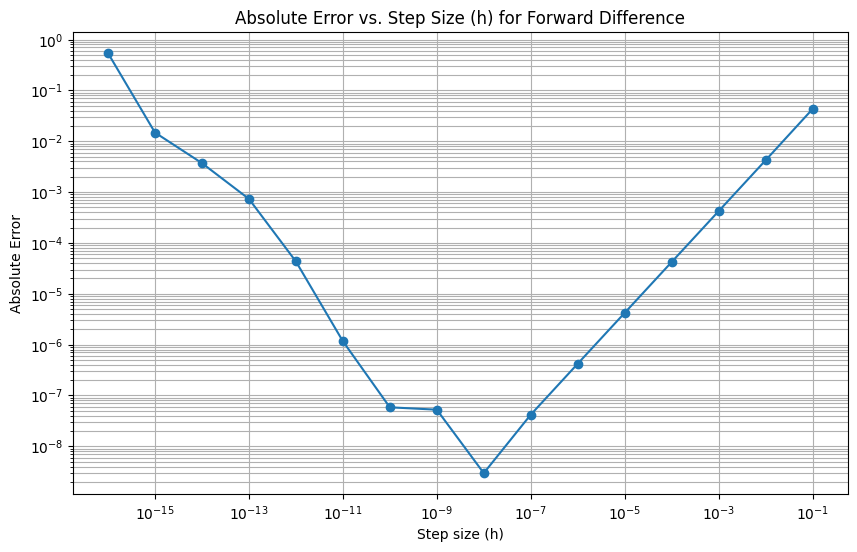

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.loglog(h, absolute_error, 'o-')
plt.xlabel('Step size (h)')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs. Step Size (h) for Forward Difference')
plt.grid(True, which="both", ls="-")
plt.show()

2. **(Analysis)** Using Taylor expansion, show that the truncation error behaves like O(h).

We have $$D_h = \frac{f(x + h) - f(x)}{h} = \frac{f(x) + hf'(x) + \frac{h^2}{2}f''(x) + ... + \frac{h^n}{n!}f^{(n)}(x) - f(x)}{h}$$
$$= f'(x) + \frac{h}{2}f''(x) + ... + \frac{h^{n-1}}{n!}f^{(n)}(x)$$
Thus, the truncation error
$$D_h - f'(x) \approx \frac{h}{2} f''(x) = O(h)$$
assuming the other terms are close to 0.

3. **(Interpretation)** Explain why "smaller h" is not always "better" in floating point. How does this connect to the notes' theme that more refinement can fail once rounding dominates?

As $h$ gets smaller and smaller, it will approach the machine epsilon and thus the expression $1 + h$ results in computational errors. From the plot, there is an optimal value for $h$ and smaller values of $h$ result in greater error.

<div style="page-break-after: always;"></div>

# **Exercise 0.5** (Residual vs. Forward Error for a Hilbert System)
Residuals are computable; forward error is usually not. Conditioning connects them
1. **(Computational)** Let $n = 10$ and let $A \in \mathbb{R}^{n \times n}$ be the Hilbert matrix
$$A_{ij} = \frac{1}{i + j - 1}, \quad 1 \le i, j \le n$$
Define the "exact" solution vector $x_* = 1 = (1, ..., 1)^T \in \mathbb{R}^n$ and set
$$b = Ax_*$$
Compute the numerical solution $\hat{x}$ in MATLAB using `xhat = A\b`. Report:
$$\text{relative residual} = \frac{||b - A\hat{x}||_2}{||b||_2} \quad \text{relative forward error} = \frac{||\hat{x} - x_*||_2}{||x_*||_2}$$
Also report the 2-norm condition number
$$\kappa_2(A) = ||A||_2||A^{-1}||_2$$
using `cond(A)`.

Defining $n$ and the Hilbert matrix:

In [ ]:
import numpy as np

n = 10

from scipy.linalg import hilbert

A = hilbert(n)
print("Hilbert Matrix:\n", np.array_str(A, precision=3, suppress_small=True))

Hilbert Matrix:
 [[1.    0.5   0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1  ]
 [0.5   0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091]
 [0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083]
 [0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077]
 [0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071]
 [0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067]
 [0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062]
 [0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059]
 [0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059 0.056]
 [0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059 0.056 0.053]]


Defining exact solution $x_*$ and setting $b$:

In [ ]:
x_star = np.ones(n, dtype=float)
b = A @ x_star

print("Exact Solution Vector:", x_star, "\n")
print("b:", b)

Exact Solution Vector: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 

b: [2.92896825 2.01987734 1.60321068 1.34680042 1.16822899 1.03489566
 0.93072899 0.84669538 0.77725094 0.7187714 ]


Computing the numerical solution $\hat{x}$:

In [ ]:
x_hat = np.linalg.solve(A, b)
b_hat = A @ x_hat

print("Numerical Solution:", x_hat, "\n")
print("b:", b_hat)

Numerical Solution: [1.         0.99999996 1.00000087 0.99999211 1.00003756 0.99989682
 1.00016919 0.99983655 1.00008579 0.99998114] 

b: [2.92896825 2.01987734 1.60321068 1.34680042 1.16822899 1.03489566
 0.93072899 0.84669538 0.77725094 0.7187714 ]


Computing relative residual and relative forward error:

In [ ]:
relative_residual = np.linalg.norm(b - A @ x_hat, 2) / np.linalg.norm(b, 2)
relative_forward_error = np.linalg.norm(x_hat - x_star, 2) / np.linalg.norm(x_star, 2)
kappa_2_A = np.linalg.cond(A, 2)

print(f"Relative Residual: {relative_residual:.5e} \n")
print(f"Relative Forward Error: {relative_forward_error:.5e} \n")
print(f"2-norm Condition Number kappa_2(A): {kappa_2_A:.5e} \n")

Relative Residual: 1.20196e-16 

Relative Forward Error: 8.67039e-05 

2-norm Condition Number kappa_2(A): 1.60244e+13 



The relative residual yielded a really small number, implying that the numerical solution satisfies the original system quite well. However, the relative forward error yielded a number that is small, but is much larger than the relative error in comparison. This suggests that the difference between the computed solution and the true solution is quite large. Upon calculating the 2-norm condition number, it returned a very large number, implying that the output of this system is very sensitive to small changes in the input, making it an ill-conditioned system.

2. **(Analysis)** Show that
$$\hat{x} - x_* = A^{-1}(b - A\hat{x}) = A^{-1}r, \quad r = b - A\hat{x}$$
Deduce the bound
$$\frac{||\hat{x} - x_*|_2}{||x_*||_2} \le \kappa_2(A) \frac{||r||_2}{||b||_2}$$

By definition,
$$Ax_* = b$$
and
$$A\hat{x} = b - r = b - (b - A\hat{x})) = b - b + A\hat{x} = A\hat{x}$$
Thus,
$$Ax_* - A\hat{x} = b - (b - r) = r $$
Another way to write this,
$$A(x_* - \hat{x}) = r \implies x_* - \hat{x} = A^{-1}r$$
Since we are working with norms and interested in the magnitude of the error, we can write
$$\hat{x} - x_* = A^{-1}r$$
Taking 2-norm of both sides,
$$||\hat{x} - x_*||_2 = ||A^{-1}r||_2 \le ||A^{-1}||_2||r||_2$$
Evaluating for $||x_*||_2$,
$$b = Ax_* \implies ||b||_2 = ||Ax_*||_2 \le ||A||_2||x_*||_2$$
$$\implies ||x_*||_2 \ge \frac{||b||_2}{||A||_2}$$
Dividing by the norm of the exact solution yields
$$\frac{||\hat{x} - x_*||_2}{||x_*||_2} \le \frac{||A^{-1}||_2||r||_2}{||x_*||_2} \le \frac{||A^{-1}||_2||r||_2}{||b||_2 / ||A||_2} = \frac{||A||_2||A^{-1}||_2||r||_2}{||b||_2} = \kappa_2(A) \frac{||r||_2}{||b||_2}$$
Thus,
$$\frac{||\hat{x} - x_*||_2}{||x_*||_2} \le \kappa_2(A) \frac{||r||_2}{||b||_2}$$

3. **(Interpretation)** Compare the sizes of the relative residual and the relative forward error you computed. Give a concrete example from your output where the residual is small but the forward error is much larger. Explain why this discrepancy is expected for an ill-conditioned matrix and is not necessarily a solver failure.

The relative residual is $1.20196 \times 10^{-16}$ and the relative forward error is $8.67039 \times 10^{-5}$. As previously shown, the values of b for the system $Ax_* = b$ and $A\hat{x} = b$ are pretty much the same, with error being barely noticeable, resulting in a very small relative residual. However, the values for the vector $x_*$ are all 1 while the values for the vector $\hat{x}$ have values that differ slightly from 1. For instance, 0.99999996, which results in a larger relative forward error. This is expected per the defiitions of relative residual and relative forward error. From the Analysis section, we see that relative forward error can also be expressed as $\kappa_2(A) \frac{||r||_2}{||b||_2}$ and is large when the condition number is large. In this case, the condition number is $1.60244 \times 10^{13}$, so we expect the relative forward error to be large.

<div style="page-break-after: always;"></div>

# **Exercise 0.6** (Backward Error Viewpoint for a Hilbert System).
Backward error interprets a computed solution as exact for a nearby problem.
1. **(Computational)** Using the same Hilbert system from the previous exercise $(n = 10, A = \text{hilb}(10), x_* = 1, b = Ax_*)$, let $\hat{x}$ be the numerical solution computed by MATLAB. Compute the residual
$$r = b - A\hat{x}$$
Verify numerically that $\hat{x}$ solves the perturbed system
$$Ax = b - r$$
exactly (up to floating point evaluation)

Redefining previous variables and creating new variable $r$:

In [ ]:
n = 10
A = hilbert(n)
x_star = np.ones(n, dtype=float)
b = A @ x_star
x_hat = np.linalg.solve(A, b)

print(f"Hilbert Matrix: \n {np.array_str(A, precision=3, suppress_small=True)} \n")
print(f"Exact solution vector: {x_star} \n")
print(f"b: {b} \n")
print(f"Numerical solution: {x_hat} \n")

r = b - A @ x_hat
print(f"r: {r} \n")

left_side = A @ x_hat
print(f"Left Side: {left_side} \n")

right_side = b - r
print(f"b - r {right_side} \n")

differences = left_side - right_side
print(f"Differences: {differences} \n")

Hilbert Matrix: 
 [[1.    0.5   0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1  ]
 [0.5   0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091]
 [0.333 0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083]
 [0.25  0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077]
 [0.2   0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071]
 [0.167 0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067]
 [0.143 0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062]
 [0.125 0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059]
 [0.111 0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059 0.056]
 [0.1   0.091 0.083 0.077 0.071 0.067 0.062 0.059 0.056 0.053]] 

Exact solution vector: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 

b: [2.92896825 2.01987734 1.60321068 1.34680042 1.16822899 1.03489566
 0.93072899 0.84669538 0.77725094 0.7187714 ] 

Numerical solution: [1.         0.99999996 1.00000087 0.99999211 1.00003756 0.99989682
 1.00016919 0.99983655 1.00008579 0.99998114] 

r: [-4.44089210e-16  0.00000000e+00  0.

Upon calculating the expression $Ax = b - r$, the variable differences takes the difference between the left side and the right side of the equation and indeed the computer solves the perturbed system exactly as differences returned the zero vector.

2. **(Analysis)** Show that the smallest perturbation to the right-hand side that makes $\hat{x}$ an exact solution is $\delta b = -r$. Conclude that a natural backward-error measure is
$$\frac{||\delta b||_2}{||b||_2} = \frac{||r||_2}{||b||_2}$$

We have $$r = b - A\hat{x} \implies A\hat{x} + r = b \implies A\hat{x} = b - r$$
and by the definition $\delta b = -r$, we have
$$A\hat{x} = b + \delta b$$
Thus,
$$\delta b = A\hat{x} - b = -r$$
Taking the 2-norm of both sides, we have
$$||\delta b||_2 = ||r||_2 \implies \frac{||\delta b||_2}{||b||_2} = \frac{||r||_2}{||b||_2}$$

3. **(Interpretation)** Explain why backward error is often easier to compute and interpret than forward error. Using the Hilbert matrix example, explain how a small backward error can still be consistent with a relatively large forward error.

Calculating the backward error does not require prior knowledge of the exact solution. Additionally, backward error utilizes approximate precision rather than precise precision. Using the equality for the backward error measure, the right hand side is the same as the bound for the relative residual and the realtive forward error. The only difference is that in the relative forward error, you multiply the term $\frac{||r||_2}{||b||_2}$ by the condition number, which in the Hibert matrix case is very large. Thus, even with a small backward error, the system can still have a large forward error.

<div style="page-break-after: always;"></div>

# **Exercise 0.7** (Norm Inequalities as Practical Bounds).
Norm equivalence is theoretically reassuring but can be quantitatively pessimistic.
1. **(Computational)** Generate random vectors $x \in \mathbb{R}^n$ for several dimensions (e.g., n = 5, 50, 500). Compute $||x||_1, ||x||_2, \text{ and }, ||x||_\infty$ and numerically verify inequalities like
$$||x||_\infty \le ||x||_2 \le ||x||_1 \le n||x||_\infty$$
Track how sharp or loose the bounds look as n increases.

In [ ]:
import numpy as np

def compute_and_verify_norms(n_dim):
    # Generate a random vector
    x = np.random.rand(n_dim)

    # Compute norms
    norm_1 = np.linalg.norm(x, 1)
    norm_2 = np.linalg.norm(x, 2)
    norm_inf = np.linalg.norm(x, np.inf)
    n_norm_inf = n_dim * norm_inf

    # Print results

    print(f"\n--- For n = {n_dim} ---")
    print(f"Vector x: {x[:5]}... (first 5 elements)")
    print(f"||x||_inf (max abs value): {norm_inf:.5e}")
    print(f"||x||_2 (Euclidean norm): {norm_2:.5e}")
    print(f"||x||_1 (Manhattan norm): {norm_1:.5e}")
    print(f"n||x||_inf (n times max abs value): {n_norm_inf:.5e}")

    # Verify inequalities
    print("\nVerifying inequalities:")
    print(f"||x||_inf <= ||x||_2: {norm_inf <= norm_2} ({norm_inf:.5e} <= {norm_2:.5e})")
    print(f"||x||_2 <= ||x||_1: {norm_2 <= norm_1} ({norm_2:.5e} <= {norm_1:.5e})")
    print(f"||x||_1 <= n * ||x||_inf: {norm_1 <= n_dim * norm_inf} ({norm_1:.5e} <= {n_dim * norm_inf:.5e})")

# Dimensions to test
dimensions = [5, 50, 500]

for n in dimensions:
    np.random.seed(42) # For reproducibility
    compute_and_verify_norms(n)


--- For n = 5 ---
Vector x: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]... (first 5 elements)
||x||_inf (max abs value): 9.50714e-01
||x||_2 (Euclidean norm): 1.40096e+00
||x||_1 (Manhattan norm): 2.81193e+00
n||x||_inf (n times max abs value): 4.75357e+00

Verifying inequalities:
||x||_inf <= ||x||_2: True (9.50714e-01 <= 1.40096e+00)
||x||_2 <= ||x||_1: True (1.40096e+00 <= 2.81193e+00)
||x||_1 <= n * ||x||_inf: True (2.81193e+00 <= 4.75357e+00)

--- For n = 50 ---
Vector x: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]... (first 5 elements)
||x||_inf (max abs value): 9.69910e-01
||x||_2 (Euclidean norm): 3.74588e+00
||x||_1 (Manhattan norm): 2.22962e+01
n||x||_inf (n times max abs value): 4.84955e+01

Verifying inequalities:
||x||_inf <= ||x||_2: True (9.69910e-01 <= 3.74588e+00)
||x||_2 <= ||x||_1: True (3.74588e+00 <= 2.22962e+01)
||x||_1 <= n * ||x||_inf: True (2.22962e+01 <= 4.84955e+01)

--- For n = 500 ---
Vector x: [0.37454012 0.95071431 0.73199394 0.

2. **(Analysis)** Prove the inequalities
$$||x||_\infty \le ||x||_2 \le ||x||_1, \quad ||x||_1 \le n||x||_\infty$$
directly from the definitions.

Let $x = (x_1, ..., x_n) \in \mathbb{R}$. Then, for some $k \in \mathbb{N}, ||x||_\infty = \max\limits_{1 \le i \le n} |x_i| = |x_k| = M$. Thus,
$$||x||_2^2 = \sum\limits_{i=1}^n |x_i|^2 \ge |x_k|^2 = M^2 = ||x||_\infty^2$$
Taking square root of both sides, we have
$$||x||_2 \ge ||x||_\infty \implies ||x||_\infty \le ||x||_2$$
Next,
$$||x||_2^2 = \sum\limits_{n=1}^n |x_i|^2 \le \Bigg(\sum\limits_{n=1}^n |x_i|\Bigg)^2 = \sum\limits_{i=1}^n |x_i|^2 + 2 \sum\limits_{1 \le i < j \le n} |x_i| |x_j| = ||x||_1^2$$
Taking square root of both sides, we have
$$||x||_2 \le ||x||_1$$
Next,
$$||x||_1 = \sum\limits_{i=1}^n |x_i| \le \sum\limits_{i=1}^n M = nM = n||x||_\infty$$
Thus,
$$||x||_1 \le n||x||_\infty$$
As desired, we have
$$||x||_\infty \le ||x||_2 \le ||x||_1 \le n||x||_\infty$$

3. **(Interpretations)** Which norm best matches each statement, and why?
* "My worst component error is small."
* "My total accumulated error is small."
* "My error energy is small."

Explain how norm choice changes the story you tell about a computation.


The first statement describes the infinity norm as it takes the absolute value of the maximum component of a vector. This is usually interpreted as the worst-case error or maximum deviation. The second statement describes the 1-norm as it takes the sum of the absolute value of a vector's components, measuring the total magnitude. This is interpreted as the cumulative or total error across all components. The last statement describes the 2-norm as it measures the overall energy or magnitude of a vector. This reflects the average or global behavior.

<div style="page-break-after: always;"></div>

# **Exercise 0.8** (Induced Matrix Norm: Two Definitions and Meaning)
Induced norms quantify worst-case amplification of vectors.
1. **(Computational)** For a random matrix $A \in \mathbb{R}^{n \times n}$ (try n = 5, 20), estimate the induced 2-norm by sampling random unit vectors $x$ and computing $||Ax||_2$. Compare this estimate to `norm(A, 2)` in MATLAB.

In [ ]:
import numpy as np

def estimate_induced_2_norm(n, num_samples = 10000):
    # Generate a random n x n matrix
    A = np.random.rand(n, n)

    # Analytical induced 2-norm
    analytical_norm_2 = np.linalg.norm(A, 2)

    # Estimate induced 2-norm by sampling unit vectors
    max_Ax_norm = 0.0
    for _ in range(num_samples):
        # Generate a random unit vector x
        x = np.random.rand(n)
        x = x / np.linalg.norm(x, 2) # Normalize to make it a unit vector

        # Compute ||Ax||_2
        Ax = A @ x
        Ax_norm = np.linalg.norm(Ax, 2)

        # Update max_Ax_norm
        if Ax_norm > max_Ax_norm:
            max_Ax_norm = Ax_norm

    print(f"\n--- For n = {n} ---")
    print(f"Estimated induced 2-norm (sampling): {max_Ax_norm:.5e}")
    print(f"Analytical induced 2-norm (np.linalg.norm): {analytical_norm_2:.5e}")

    # Calculate and print the relative difference
    relative_difference = abs(max_Ax_norm - analytical_norm_2) / analytical_norm_2
    print(f"Relative difference: {relative_difference:.5e}")

# Dimensions to test
dimensions = [5, 20]

# Set random seed for reproducibility
np.random.seed(42)

for n_dim in dimensions:
    estimate_induced_2_norm(n_dim, num_samples = 10000)


--- For n = 5 ---
Estimated induced 2-norm (sampling): 2.34718e+00
Analytical induced 2-norm (np.linalg.norm): 2.35153e+00
Relative difference: 1.84976e-03

--- For n = 20 ---
Estimated induced 2-norm (sampling): 9.71892e+00
Analytical induced 2-norm (np.linalg.norm): 9.96543e+00
Relative difference: 2.47367e-02


2. **(Analytical)** Starting from the definition
$$||A|| = \sup\limits_{x \neq 0} \frac{||Ax||}{||x||}$$
prove that
$$||A|| = \sup\limits_{||x|| = 1} ||Ax||$$
and use this to show submultiplicativity:
$$||AB|| \le ||A|| ||B||$$

Define
$$y = \frac{x}{||x||}$$
Then,
$$||y|| = \Big|\Big|\frac{x}{||x||}\Big|\Big| = 1$$
Substitute
$$x = ||x||y$$
Then,
$$Ax = A(||x||y) = ||x||Ay$$
Homogeneity implies
$$|| ||x||Ay|| = ||x|| ||Ay||$$
Thus,
$$\frac{||Ax||}{||x||} = \frac{||x|| ||Ay||}{||x||} = ||Ay|| \le ||A|| ||y|| = ||A||$$
So, for all $x \neq 0$, there exists a unit vector  $y$ such that $\frac{||Ax||}{||x||} = ||Ay||$, so take $x = y$. Then,
$$||A|| = \sup\limits_{||x|| = 1} ||Ax||$$
Now,
$$||AB|| = \sup\limits_{||x|| = 1} ||ABx|| \le ||A||||Bx|| \le ||A||||B||||x|| = ||A||||B||$$
Thus,
$$||ABx|| \le ||A||||B||$$

3. **(Interpretation)** Between the two equivalent definitions, which better supports the interpretation "$||A||$ is the maximum amplification factor"? Explain what "worst-case" means here and why it is useful for error bounds.

I think the second equality
$$||A|| = \sup\limits_{||x|| = 1} ||Ax||$$
better supports the interpretation. Worst-case here means that when the norm of $x$ is 1, the biggest amplification factor is the norm of A. It is useful for error bounds as the largest bound is already known.